# 1. Importation des Librairies et Chargement des Données

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast  # Pour convertir les chaînes de caractères en listes
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from collections import Counter



In [18]:
# Charger uniquement le fichier de films
try:
    df = pd.read_csv("../donnees/tmdb_5000_movies_nettoyer.csv")
except FileNotFoundError:
    print("Erreur: Assurez-vous que le fichier 'tmdb_5000_movies.csv' est dans le même dossier que ce notebook.")
    # Si vous utilisez Google Colab, décommentez les lignes suivantes pour charger le fichier :
    # from google.colab import files
    # uploaded = files.upload()
    # df = pd.read_csv("tmdb_5000_movies.csv")

print(f"Dataset chargé avec {df.shape[0]} lignes et {df.shape[1]} colonnes.")

Dataset chargé avec 4800 lignes et 22 colonnes.


# 2. Sélection et Prétraitement des Caractéristiques

In [19]:
# Nous gardons les colonnes qui nous intéressent pour le clustering thématique
df_processed = df[['id', 'title', 'overview', 'genres', 'keywords']].copy()

# Supprimer les lignes où les informations essentielles sont manquantes
df_processed.dropna(subset=['overview', 'genres', 'keywords'], inplace=True)
print(f"Après suppression des valeurs manquantes, il reste {df_processed.shape[0]} films.")

# --- Fonctions d'aide pour extraire les informations des colonnes JSON ---

def extract_names(text):
    """Extrait les valeurs 'name' d'une chaîne de caractères de type JSON."""
    try:
        # ast.literal_eval est plus sûr que eval pour convertir la chaîne en liste
        names = [item['name'] for item in ast.literal_eval(text)]
        # Nettoyage : supprimer les espaces et mettre en minuscule
        return [name.replace(" ", "").lower() for name in names]
    except:
        return []

# Appliquer la fonction pour extraire et nettoyer les genres et mots-clés
df_processed['genres'] = df_processed['genres'].apply(extract_names)
df_processed['keywords'] = df_processed['keywords'].apply(extract_names)

# Le synopsis ('overview') doit être transformé en une liste de mots
df_processed['overview'] = df_processed['overview'].apply(lambda x: x.split())

# --- Création de la "soupe de mots" (colonne 'tags') ---
# On combine le synopsis, les genres et les mots-clés
df_processed['tags'] = df_processed['overview'] + df_processed['genres'] + df_processed['keywords']

# Créer un DataFrame final propre pour la modélisation
df_final = df_processed[['id', 'title', 'tags', 'genres', 'keywords']].copy() # On garde genres/keywords pour l'analyse
# Convertir la liste de mots 'tags' en une seule chaîne de caractères
df_final['tags'] = df_final['tags'].apply(lambda x: " ".join(x).lower())





Après suppression des valeurs manquantes, il reste 4800 films.


# 3. Vectorisation avec TF-IDF


In [20]:
# Initialiser le vectoriseur TF-IDF
# - max_features=5000 : on garde les 5000 mots les plus pertinents
# - stop_words='english' : on enlève les mots courants anglais (ex: 'the', 'a', 'in')
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

# Appliquer le vectoriseur sur notre "soupe de mots"
vectors = tfidf.fit_transform(df_final['tags']).toarray()

print(f"Matrice de caractéristiques créée avec une forme de : {vectors.shape}")

Matrice de caractéristiques créée avec une forme de : (4800, 5000)


# 4. Modélisation avec K-Means

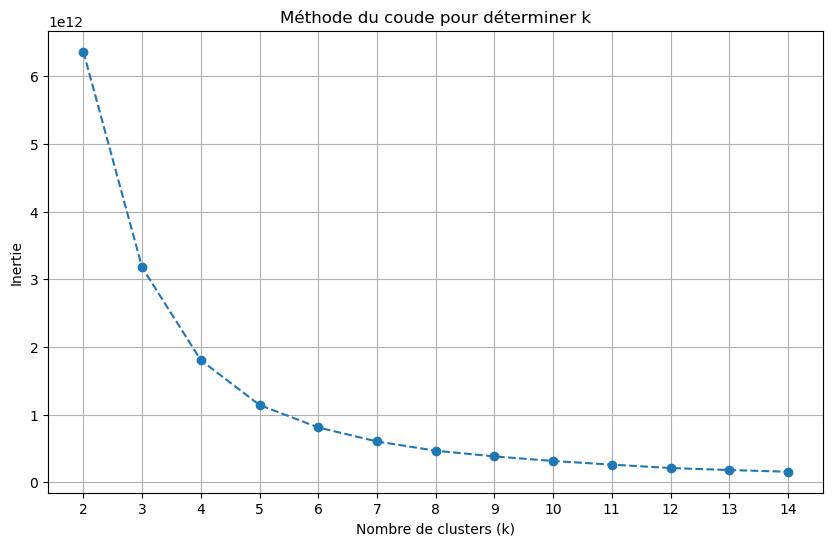

In [21]:

# --- Déterminer le nombre optimal de clusters (k) via la méthode du coude ---
vectors =np.load("../donnees/donnees_fusionnees.npy", allow_pickle=True)

inerties = []
k_range = range(2, 15) # On teste de 2 à 15 clusters
for i in k_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(vectors)
    inerties.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inerties, marker='o', linestyle='--')
plt.title('Méthode du coude pour déterminer k')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# NOTE : D'après le graphique, un "coude" (point où la descente ralentit) semble se situer
# entre 6 et 9. Choisissons une valeur dans cette plage pour le modèle final.
# Pour votre rapport, vous devrez justifier votre choix de 'k' en vous basant sur ce graphique.

# --- Entraînement du modèle final ---

In [22]:
df_final = np.load("../donnees/tmdb_5000_movies_nettoyer.csv", allow_pickle=True)

UnpicklingError: Failed to interpret file '../donnees/tmdb_5000_movies_nettoyer.csv' as a pickle

In [23]:
OPTIMAL_K = 5  # À ajuster en fonction de votre analyse du graphique du coude
kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(vectors)

# Ajouter les labels de cluster au DataFrame
df_final['cluster'] = cluster_labels


# 5. Analyse et Interprétation des Clusters

In [24]:
print(f"\n==========================================")
print(f"   Analyse des {OPTIMAL_K} Clusters Trouvés")
print(f"==========================================")

for i in range(OPTIMAL_K):
    print(f"\n--- CLUSTER {i} ---")
    
    # Récupérer tous les films appartenant à ce cluster
    cluster_movies = df_final[df_final['cluster'] == i]
    
    # Afficher les 10 premiers titres de films pour avoir une idée qualitative
    print("\nQuelques exemples de films :")
    for title in cluster_movies['title'].head(10).tolist():
        print(f"  - {title}")
    
    # Analyser les genres les plus fréquents dans ce cluster pour lui donner un sens
    # On utilise Counter pour compter efficacement les occurrences
    all_genres_in_cluster = [genre for sublist in cluster_movies['genres'] for genre in sublist]
    genre_counts = Counter(all_genres_in_cluster)
    
    print("\nGenres les plus fréquents :")
    for genre, count in genre_counts.most_common(5):
        print(f"  - {genre} ({count} films)")
        
    # Faire de même avec les mots-clés
    all_keywords_in_cluster = [keyword for sublist in cluster_movies['keywords'] for keyword in sublist]
    keyword_counts = Counter(all_keywords_in_cluster)

    print("\nMots-clés dominants :")
    for keyword, count in keyword_counts.most_common(5):
        print(f"  - {keyword} ({count} fois)")


   Analyse des 5 Clusters Trouvés

--- CLUSTER 0 ---

Quelques exemples de films :
  - Avatar
  - Pirates of the Caribbean: At World's End
  - Spider-Man 3
  - Harry Potter and the Half-Blood Prince
  - Superman Returns
  - Quantum of Solace
  - Pirates of the Caribbean: Dead Man's Chest
  - The Chronicles of Narnia: Prince Caspian
  - The Avengers
  - Pirates of the Caribbean: On Stranger Tides

Genres les plus fréquents :
  - drama (1484 films)
  - comedy (1171 films)
  - thriller (841 films)
  - action (787 films)
  - romance (626 films)

Mots-clés dominants :
  - independentfilm (234 fois)
  - womandirector (179 fois)
  - duringcreditsstinger (166 fois)
  - murder (140 fois)
  - basedonnovel (115 fois)

--- CLUSTER 1 ---

Quelques exemples de films :
  - Spectre
  - Batman v Superman: Dawn of Justice
  - Captain America: Civil War
  - The Legend of Tarzan
  - X-Men: Apocalypse
  - The Jungle Book
  - Alice Through the Looking Glass
  - Pan
  - Gods of Egypt
  - The BFG

Genres les